# Занятие 21. ML workflow и kNN — presentation

Ноутбук для работы **у доски**. Полный текст и самоучитель:
`Урок_21_Workflow_kNN.ipynb`.

Вопросы — для диалога с классом. Блоки **Вывод** — то, что фиксируем после обсуждения.

К концу урока фиксируем:

- тип задачи и роль train / validation / test;
- kNN vs baseline на validation;
- один раз — проверка на test.


## 1. Типы ML-задач

**Обсудим:** в какой задаче у объектов **нет** готовых правильных ответов?


| Задача | Есть метки? | Что предсказываем? |
|---|---|---|
| кластеризация | нет | группы похожих объектов |
| классификация | да | категорию |
| регрессия | да | число |


**Обсудим:** наш датасет (опухоль → злокачественная / доброкачественная) — классификация или регрессия? Почему?


> **Вывод.** Есть метки → обучение **с учителем** (классификация / регрессия).
> Нет меток → **без учителя**. Урок — классификация с учителем.


## 2. Сквозной цикл ML-проекта

1. Данные → 2. Признаки → 3. Предобработка → 4. Обучение → 5. Метрики на validation → 6. Сравнение гипотез → 7. Анализ ошибок → один раз test.

**Обсудим:** почему «обучить модель» — не весь проект? На каком шаге крутят разные `k`?


> **Вывод.** Workflow — **цикл**. Идеи и `k` сравнивают на **validation**; **test** — финал уже выбранного решения.


## 3. Метод k ближайших соседей (kNN)

**Идея:** k ближайших из train → голосование классов (`KNeighborsClassifier`) или среднее (`KNeighborsRegressor`).

Похожесть — евклидово расстояние:

$$d(a,b)=\sqrt{\sum_j (a_j-b_j)^2}$$

**Обсудим:** «обучается» ли kNN весами, как линейная модель? Что делает `.fit`?


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer(as_frame=True)
X_all, y_all = data.data, data.target
print('Объектов:', X_all.shape[0], '| признаков:', X_all.shape[1])
print('Доля класса 1 (доброкачественные):', round(y_all.mean(), 3))

a, b = X_all.iloc[0, :3].to_numpy(), X_all.iloc[1, :3].to_numpy()
print('Евклидово расстояние (3 признака):', round(float(np.sqrt(np.sum((a - b) ** 2))), 2))
X_all.iloc[:, :4].head()


Объектов: 569 | признаков: 30
Доля класса 1 (доброкачественные): 0.627
Евклидово расстояние (3 признака): 12.78


,mean radius,mean texture,mean perimeter,mean area
0,17.99,10.38,122.80,1001.0
1,20.57,17.77,132.90,1326.0
2,19.69,21.25,130.00,1203.0
3,11.42,20.38,77.58,386.1
4,20.29,14.34,135.10,1297.0


**Обсудим:** если один признак в тысячах, а другой в единицах — кто сильнее влияет на расстояние? `k` модель выучит сама или задаём мы?


> **Вывод.** `.fit` у kNN **запоминает** train. Расстояние чувствительно к **масштабу**. `k` — гиперпараметр.


## 4. Train, validation и test

| Часть | Зачем | Аналогия |
|---|---|---|
| **Train** | обучение и преобразования | учебник |
| **Validation** | много раз сравнивать идеи и `k` | пробные варианты |
| **Test** | **один раз** проверить выбранное | контрольная |

**Обсудим:** почему нельзя подбирать `k` по test?


In [2]:
from sklearn.model_selection import train_test_split

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, random_state=42, stratify=y_train_val
)
print('train / val / test:', len(X_train), len(X_val), len(X_test))


train / val / test: 341 114 114


**Обсудим:** зачем здесь `stratify=y`? Что даёт `random_state=42`?


> **Вывод.** Validation — для экспериментов; test после выбора **не крутят**.
> `stratify` держит доли классов; `random_state` фиксирует split.


## 5. От вопроса к ML-задаче

**Обсудим:** «какие опухоли опасны?» — уже ML-задача? Чего не хватает?


| Пункт | В нашем примере |
|---|---|
| объект | одна опухоль (строка) |
| момент прогноза | измерения биопсии; без «лечения через год» |
| цель | класс 0 или 1 |
| действие | при подозрении на 0 — дообследование |
| метрика | recall для класса 0 |


> **Вывод.** Фиксируем объект, момент, цель, действие, метрику.
> У нас: не пропустить злокачественную (0) по 30 числовым признакам.


## 6. Критерий успеха проекта

**Обсудим:** критерий «recall ≥ 0.85» пишут до эксперимента или после цифр? Почему так?


> **Вывод.** Критерий успеха — **до** просмотра результатов. Иначе легко подогнать планку.


## 7. Единица наблюдения и момент прогноза

**Обсудим:** что здесь один объект прогноза? Можно ли в признаки добавить «результат лечения через полгода»?


> **Вывод.** Один прогноз — **одна опухоль**. Только информация на **момент прогноза**; будущее → утечка.


## 8. Метрика следует из цены ошибок

| | Прогноз «злокач.» (0) | Прогноз «доброкач.» (1) |
|---|---|---|
| **Истина злокач. (0)** | **TP** | **FN** (пропуск!) |
| **Истина доброкач. (1)** | **FP** (ложная тревога) | **TN** |

$$\mathrm{recall}=\frac{TP}{TP+FN},\quad
\mathrm{precision}=\frac{TP}{TP+FP},\quad
\mathrm{accuracy}=\frac{TP+TN}{N}$$

**Обсудим:** какая ошибка дороже в нашей задаче — FN или FP?


**Обсудим:** почему для recall злокачественных пишут `pos_label=0`? Когда accuracy обманывает?


> **Вывод.** Метрику выбирают из **цены ошибок**.
> `pos_label` — «про какой класс считаем»; у нас для злокачественных — `0`.


## 9. Независимость объектов и способ разбиения

| Сценарий | Как делить |
|---|---|
| объекты независимы | случайно |
| несколько строк на пациента | весь пациент в одной части |
| прогноз будущего | по времени |

**Обсудим:** наш датасет — какой сценарий? Что сломается, если один пациент и в train, и в test?


> **Вывод.** Split повторяет то, что будет **новым** после внедрения.
> Случайный split — только при независимых объектах.


## 10. Утечка данных

**Обсудим:**

1. Среднее для пропусков по всей таблице до split — можно?
2. Подобрать `k` по test и потом назвать test-accuracy «честной» — можно?


> **Вывод.** Утечка — модель увидела то, чего не будет в реальном прогнозе.
> Среднее/масштаб — **только на train**; `k` и признаки — по validation.


## 11. Baseline: с чем сравнивать kNN

**Обсудим:** зачем «глупая» модель, если всё равно учим kNN? Что сделает `most_frequent`?


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score

dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_acc = accuracy_score(y_val, dummy.predict(X_val))
print('Baseline accuracy на validation:', round(dummy_acc, 3))
print(
    'Доля большего класса в train:',
    round(float(y_train.mean() if y_train.mean() > 0.5 else 1 - y_train.mean()), 3),
)


Baseline accuracy на validation: 0.623
Доля большего класса в train: 0.628


**Обсудим:** чему примерно равна accuracy baseline? Связано ли это с долей класса?


> **Вывод.** Baseline — ориентир. Если kNN не лучше — рано усложнять.
> `most_frequent` ≈ доля частого класса в train.


## 12. Инжиниринг признаков

**Обсудим:** чем новый столбец из уже известных чисел отличается от сбора новых измерений? Можно ли выбирать признак по test?


In [4]:
def add_features(df):
    out = df.copy()
    out['radius_texture_ratio'] = out['mean radius'] / out['mean texture']
    return out

X_train_fe = add_features(X_train)
X_val_fe = add_features(X_val)
X_test_fe = add_features(X_test)
print('Было признаков:', X_train.shape[1], '-> стало:', X_train_fe.shape[1])


Было признаков: 30 -> стало: 31


> **Вывод.** Признак из известных чисел — ок, если нет статистики «со всей таблицы».
> Сравнивают идеи на **validation**.


## 13. StandardScaler: fit на train, transform везде

**Обсудим:** нужно ли масштабирование для kNN? Можно ли `scaler.fit` на validation?


> **Вывод.** `fit` — среднее и σ **только на train**; `transform` — те же параметры везде.
> Fit на val/test = утечка.


## 14. Обучение kNN на масштабированных данных

**Обсудим:** что раньше — `StandardScaler.fit` или `KNeighborsClassifier.fit`?


In [5]:
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fe)
X_val_scaled = scaler.transform(X_val_fe)
X_test_scaled = scaler.transform(X_test_fe)

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
val_pred = knn.predict(X_val_scaled)
val_accuracy = accuracy_score(y_val, val_pred)
print('kNN (k=5) accuracy на validation:', round(val_accuracy, 3))
print('Baseline был:', round(dummy_acc, 3))


kNN (k=5) accuracy на validation: 0.947
Baseline был: 0.623


**Обсудим:** kNN лучше baseline? Достаточно ли одной accuracy без recall?


> **Вывод.** Сначала преобразования (fit на train), потом модель.
> kNN на scaled-данных должен быть заметно лучше baseline на validation.


## 15. Журнал экспериментов: подбор k

**Обсудим:** что будет при очень маленьком `k`? При очень большом?


,признаки,модель,k,val_acc
0,scaled,Dummy(most_frequent),NaN,0.623
1,scaled,kNN,1.0,0.939
2,scaled,kNN,3.0,0.965
3,scaled,kNN,5.0,0.947
4,scaled,kNN,11.0,0.956
5,scaled,kNN,21.0,0.930


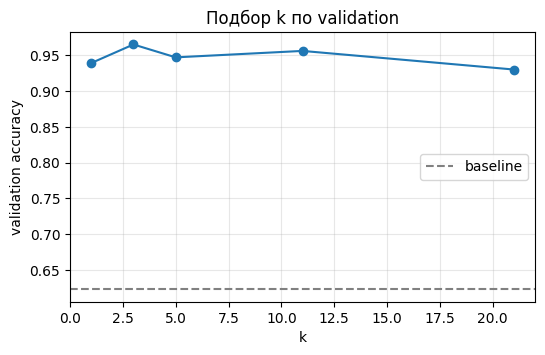

In [6]:
import matplotlib.pyplot as plt

runs = [
    {'признаки': 'scaled', 'модель': 'Dummy(most_frequent)', 'k': None, 'val_acc': round(dummy_acc, 3)}
]
for k in [1, 3, 5, 11, 21]:
    m = KNeighborsClassifier(n_neighbors=k).fit(X_train_scaled, y_train)
    runs.append({
        'признаки': 'scaled',
        'модель': 'kNN',
        'k': k,
        'val_acc': round(accuracy_score(y_val, m.predict(X_val_scaled)), 3),
    })

experiments = pd.DataFrame(runs)
display(experiments)

knn_part = experiments[experiments['модель'] == 'kNN']
plt.figure(figsize=(6, 3.5))
plt.plot(knn_part['k'], knn_part['val_acc'], marker='o')
plt.axhline(dummy_acc, color='gray', linestyle='--', label='baseline')
plt.xlabel('k')
plt.ylabel('validation accuracy')
plt.title('Подбор k по validation')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


**Обсудим:** по какой кривой / части данных выбираем `k`? Почему в журнале меняют одну вещь за раз?


> **Вывод.** `k` — по **validation**, в журнал. Маленький `k` — шумно; большой — слишком гладко.


## 16. Одинаковый протокол сравнения

**Обсудим:** можно ли сравнить «kNN без scaler на другом split» с «kNN со scaler на нашем»?


In [7]:
knn_raw = KNeighborsClassifier(n_neighbors=5).fit(X_train_fe, y_train)
acc_raw = accuracy_score(y_val, knn_raw.predict(X_val_fe))
knn_scaled = KNeighborsClassifier(n_neighbors=5).fit(X_train_scaled, y_train)
acc_scaled = accuracy_score(y_val, knn_scaled.predict(X_val_scaled))

pd.DataFrame({
    'эксперимент': ['kNN без масштабирования', 'kNN со StandardScaler'],
    'val_accuracy': [round(acc_raw, 3), round(acc_scaled, 3)],
})


,эксперимент,val_accuracy
0,kNN без масштабирования,0.930
1,kNN со StandardScaler,0.947


**Обсудим:** какая **одна** вещь отличалась? Помог ли scaler?


> **Вывод.** Сравнивают на равных: один split, одна метрика, одна гипотеза.
> Для kNN масштабирование важно.


## 17. Confusion matrix на validation

## 18. Разбор ошибок по группам

**Обсудим:** что строки и столбцы в матрице ошибок? Где FN — пропущенные злокачественные?


In [8]:
cm = confusion_matrix(y_val, val_pred)
cm_labeled = pd.DataFrame(
    cm,
    index=['истина 0 (злокач.)', 'истина 1 (доброкач.)'],
    columns=['прогноз 0', 'прогноз 1'],
)
display(cm_labeled)

tp, fn, fp, tn = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]
print('TP, FN, FP, TN (класс 0):', int(tp), int(fn), int(fp), int(tn))
print('Recall злокачественных (pos_label=0):', round(recall_score(y_val, val_pred, pos_label=0), 3))

median_radius = X_train['mean radius'].median()
group = np.where(X_val['mean radius'] >= median_radius, 'крупные', 'мелкие')
error_table = pd.DataFrame({
    'группа': group,
    'ошибка': (val_pred != y_val.to_numpy()).astype(int),
})
print('Доля ошибок внутри группы (не суммируется в 1):')
print(error_table.groupby('группа', observed=True)['ошибка'].mean().round(3).to_string())


,прогноз 0,прогноз 1
истина 0 (злокач.),37,6
истина 1 (доброкач.),0,71


TP, FN, FP, TN (класс 0): 37 6 0 71
Recall злокачественных (pos_label=0): 0.86
Доля ошибок внутри группы (не суммируется в 1):
группа
крупные    0.081
мелкие     0.019


**Обсудим:** доли ошибок «крупные» и «мелкие» должны сложиться в 1?


> **Вывод.** Матрица показывает **какие** ошибки, не только среднее.
> Доли по группам — внутри группы; в 1 не складывают.


## 19. Финальный test и внедрение

**Обсудим:** после test-метрик можно ещё покрутить `k` и снова глянуть test?


In [9]:
knn_runs = experiments[experiments['модель'] == 'kNN']
best_k = int(knn_runs.loc[knn_runs['val_acc'].idxmax(), 'k'])
final_model = KNeighborsClassifier(n_neighbors=best_k).fit(X_train_scaled, y_train)
test_pred = final_model.predict(X_test_scaled)
print(f'Финальная accuracy kNN (k={best_k}) на test:', round(accuracy_score(y_test, test_pred), 3))
print('Recall злокачественных на test:', round(recall_score(y_test, test_pred, pos_label=0), 3))
print('Baseline accuracy на validation был:', round(dummy_acc, 3))


Финальная accuracy kNN (k=3) на test: 0.947
Recall злокачественных на test: 0.929
Baseline accuracy на validation был: 0.623


**Обсудим:** зачем мониторинг после внедрения, если test хороший?


> **Вывод.** Выбрали по validation → **один раз** test → test не трогаем.
> После внедрения смотрят дрейф данных и качество: мир меняется.


## 20. Чек-лист эксперимента

**Устно по кругу:**

1. Где подбираем `k` и признаки?
2. Где делают `scaler.fit`?
3. С чем первым делом сравниваем kNN?
4. Сколько раз смотрим test для одной версии?
5. Какую ошибку боимся больше всего?


> **Вывод.** Тип задачи → split без утечек → baseline → признаки/scaler/kNN → журнал на validation → ошибки → один test.
